# Import modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.simulation import Simulation
from pipedream_solver.diagnostics import PerformanceTracker

# Read input data

In [2]:
superjunctions = pd.read_csv('../data/net2/net2_superjunctions.csv', index_col=0)
superlinks = pd.read_csv('../data/net2/net2_superlinks.csv', index_col=0)
orifices = pd.read_csv('../data/net2/net2_orifices.csv', index_col=0)
multipliers = pd.read_csv('../data/net2/net2_multipliers.csv', index_col=0)

H_epanet = pd.read_csv('../data/net2/net2_heads_epanet.csv', index_col=0)
Q_epanet = pd.read_csv('../data/net2/net2_flows_epanet.csv', index_col=0)

# Instantiate model

In [3]:
# Simulation parameters
dt = 1800
num_iter = 1000
num_tanks = 1
num_pumps = 0

# Instantiate model
model = SuperLink(superlinks, superjunctions, orifices=orifices, internal_links=1)

# Set orifice and pump controls
u_o = np.ones(num_tanks)
u_p = np.ones(num_pumps)

# Define demand input
Q_in = pd.concat([-model.superjunctions['demand_pattern'].map(multipliers.loc[i]).fillna(0.) 
                * model.superjunctions['base_demand'] for i in multipliers.index], axis=1).T
Q_in.index = Q_in.index.values * 3600
for i in range(len(Q_in) - 1):
    ix = Q_in.index[i]
    ix_next = Q_in.index[i+1] - 1
    Q_in.loc[ix_next] = Q_in.loc[ix]

# Define EPANET helper variables
is_tank = model.superjunctions['tank'].values
is_tank_fake_node = model.superjunctions['tank_fake_node'].values
tank_min = model.superjunctions['tank_min'].values
tank_max = model.superjunctions['tank_max'].values 
is_criteria = [False, False, True, False, False, False, False, False, False, False, False, False]

# Spin up model
model.spinup(n_steps=10, dt=60, Q_in=Q_in.loc[0].values, u_o=u_o)

# Add run-time performance tracker
performance_tracker = PerformanceTracker(model)
model.bind_callback(performance_tracker, 'performance_tracker')
model.performance_tracker = performance_tracker

# Set parameters for Newton iterations
model.convergence_tracker.max_learning_rate = 1.
model.convergence_tracker.beta = 2.

# Plot network

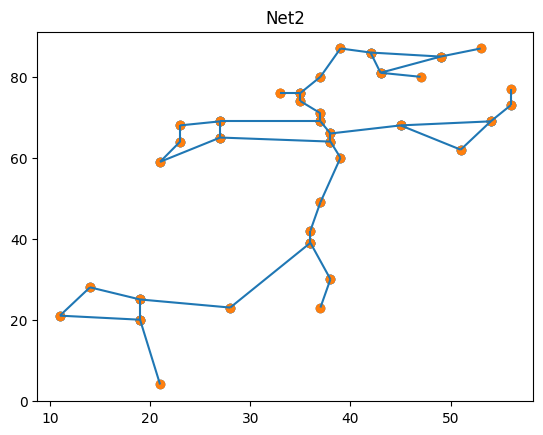

In [4]:
_ = model.plot_network_2d()
_ = plt.title('Net2')

## Run simulation

In [5]:
iterations_elapsed = {}
convergence_queues = {}
learning_queues = {}
error_queues = {}
volume_in_system = {}
volume_net_added = {}
step_time_taken = {}

In [6]:

with Simulation(model, Q_in=Q_in, t_end=H_epanet.index[-1], interpolation_method='nearest') as simulation:
    # While simulation time has not expired...
    while simulation.t <= simulation.t_end:
        # Step model forward in time
        simulation.step(dt=dt, num_iter=num_iter, u_o=u_o)
        u_o = ((model.H_j[is_tank_fake_node] > tank_min[is_tank_fake_node] + 0.1)
               & (model.H_j[is_tank_fake_node] < tank_max[is_tank_fake_node] - 0.1)).astype(np.float64)
        # Record internal depth and flow states
        simulation.record_state()
        # Print progress bar
        simulation.print_progress()
        # Record diagnostic metrics
        iterations_elapsed[simulation.t] = model.iter_elapsed
        convergence_queues[simulation.t] = model.convergence_tracker.convergence_queue
        error_queues[simulation.t] = model.convergence_tracker.error_queue
        learning_queues[simulation.t] = model.convergence_tracker.learning_queue
        volume_in_system[simulation.t] = model.volume_tracker.total_volume
        volume_net_added[simulation.t] = model.volume_tracker.cumulative_volume_flux
        step_time_taken[simulation.t] = model.performance_tracker.step_time_elapsed

[==================================================] 100.0% [2.18 s]

# Plot time series of states

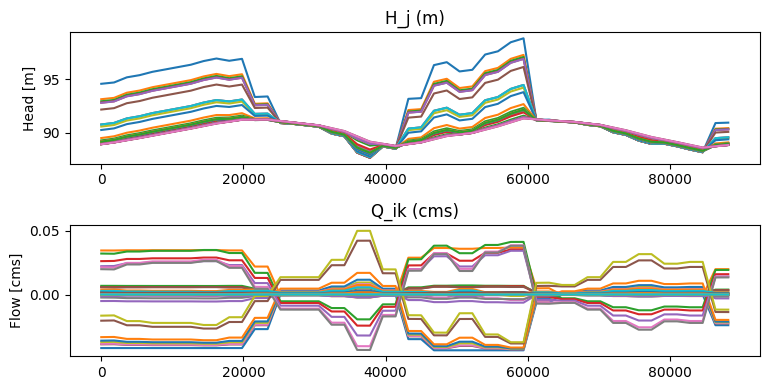

In [7]:
# Instantiate plot
fig, ax = plt.subplots(2, figsize=(8, 4))

# Plot results
simulation.states.H_j.plot(ax=ax[0], title='H_j (m)', legend=False)
simulation.states.Q_ik.plot(ax=ax[1], title='Q_ik (cms)', legend=False)

ax[0].set_ylabel('Head [m]')
ax[1].set_ylabel('Flow [cms]')

# Configure plots
plt.tight_layout()


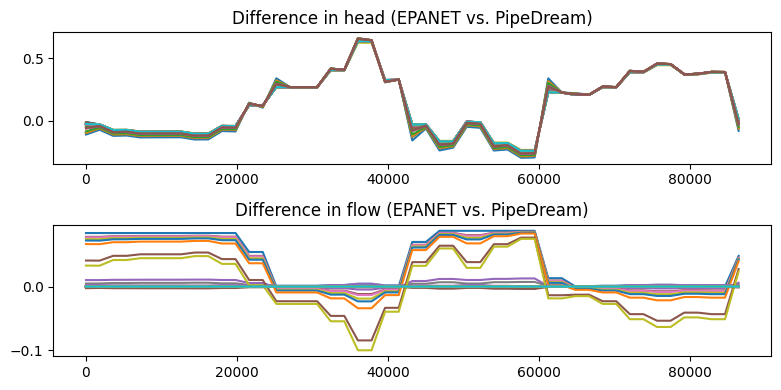

In [8]:
# Instantiate plot
fig, ax = plt.subplots(2, figsize=(8, 4))

# Plot results
(H_epanet - simulation.states.H_j).plot(ax=ax[0], 
    title='Difference in head (EPANET vs. PipeDream)', legend=False)
(Q_epanet - simulation.states.Q_ik.rename(columns=simulation.model.superlinks['name'].astype(str))).plot(ax=ax[1], 
    title='Difference in flow (EPANET vs. PipeDream)', legend=False)

# Configure plots
plt.tight_layout()

# Mass balance analysis

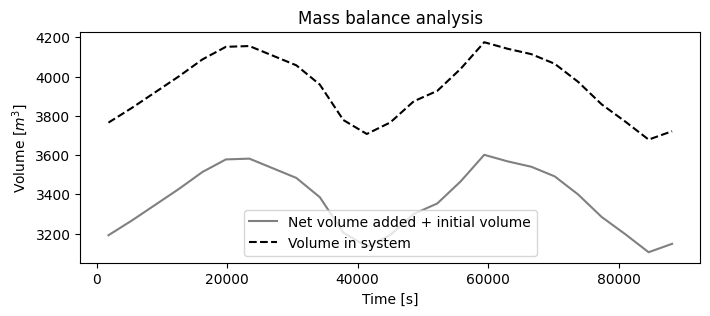

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
(pd.Series(volume_net_added) + model.volume_tracker.init_volume).plot(ax=ax, label='Net volume added + initial volume', c='0.5')
pd.Series(volume_in_system).plot(ax=ax, label='Volume in system', c='k', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Volume [$m^3$]')
plt.title('Mass balance analysis')
_ = plt.legend()

# Convergence analysis

### Step convergence criterion $||x_{new} - x_{old}||_\infty$

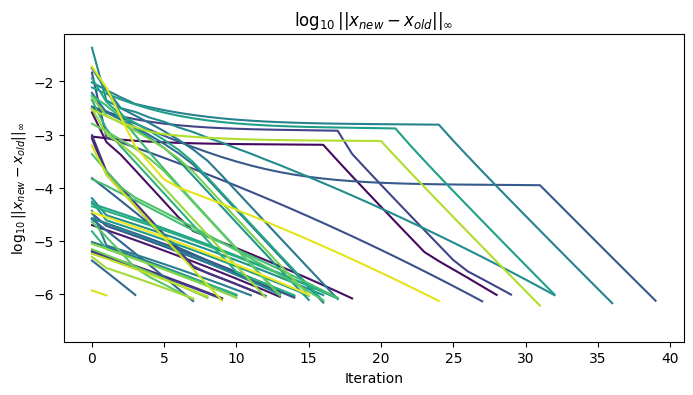

In [10]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in convergence_queues:
    ax.plot(np.log10(np.vstack(convergence_queues[key])).max(axis=1))
_ = plt.title('$\log_{10} ||x_{new} - x_{old}||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||x_{new} - x_{old}||_\infty$')

### Error convergence criterion $||f(x)||_\infty$

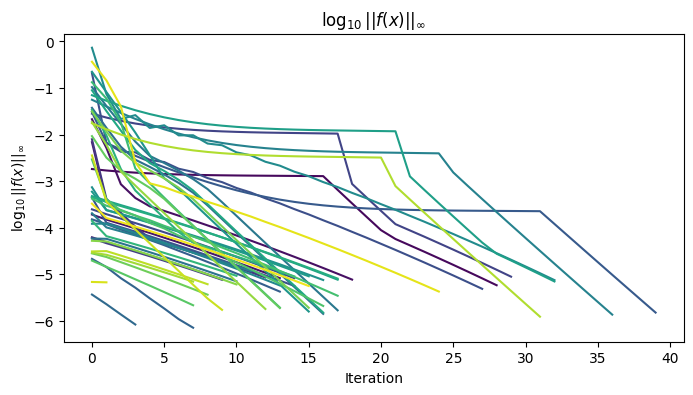

In [11]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in error_queues:
    ax.plot(np.log10(np.array(error_queues[key])))
_ = plt.title('$\log_{10} ||f(x)||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||f(x)||_\infty$')


### Newton step size

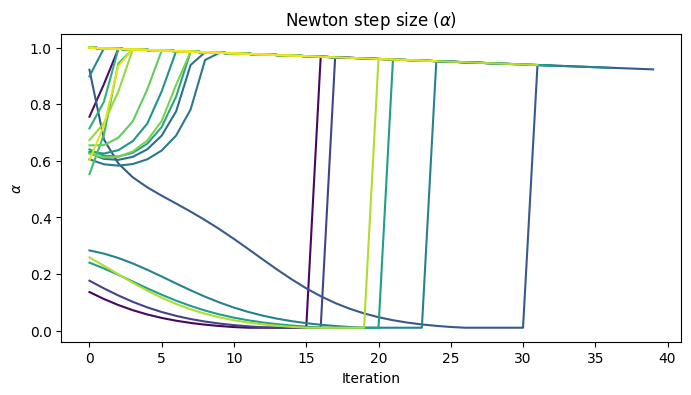

In [12]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in learning_queues:
    ax.plot(np.array(learning_queues[key]))
_ = plt.title('Newton step size ($\\alpha$)')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\\alpha$')


### Number of iterations elapsed

Text(0, 0.5, 'Iterations')

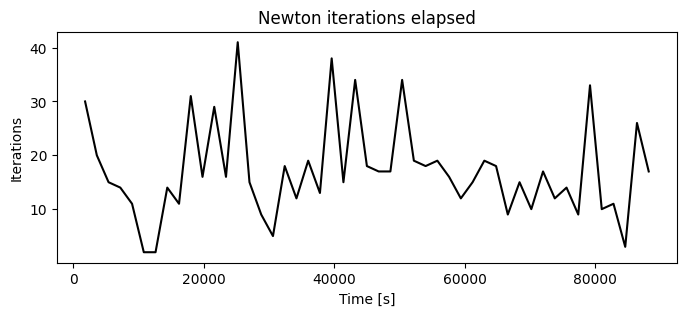

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(iterations_elapsed).plot(ax=ax, c='k')
plt.title('Newton iterations elapsed')
plt.xlabel('Time [s]')
plt.ylabel('Iterations')

### Simulation time elapsed

Text(0, 0.5, 'Clock time elapsed [s]')

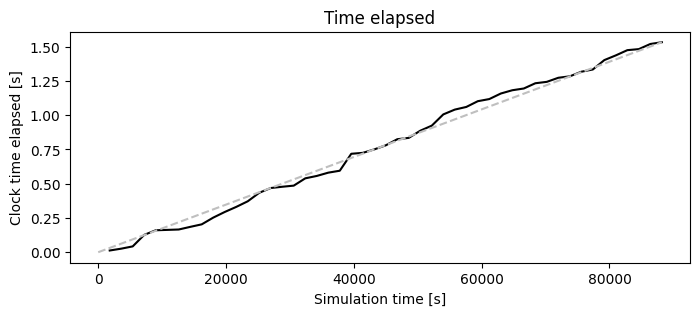

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(step_time_taken).cumsum().plot(ax=ax, c='k')
plt.plot([0, simulation.t], [0, pd.Series(step_time_taken).cumsum().iloc[-1]], c='0.75', linestyle='--')
plt.title('Time elapsed')
plt.xlabel('Simulation time [s]')
plt.ylabel('Clock time elapsed [s]')